<a href="https://colab.research.google.com/github/nishuchy/AI-works/blob/main/semantic_medical_recommendation_system_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ==========================================
# 1. Install Libraries
# ==========================================

!pip uninstall -y opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp-proto-grpc -q
!pip install pandas numpy torch transformers sentence-transformers chromadb faiss-cpu scikit-learn evaluate -q

# ==========================================
# 1. Install Libraries
# ==========================================
!pip install sentence-transformers faiss-cpu chromadb transformers -q


# ==========================================
# 1. Install Libraries
# ==========================================
!pip install sentence-transformers faiss-cpu chromadb transformers evaluate -q

# ==========================================
# 2. Imports
# ==========================================
import pandas as pd
import numpy as np
import torch
import faiss
import chromadb
from sentence_transformers import SentenceTransformer, InputExample, losses, CrossEncoder
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from transformers import pipeline
import random


# ==========================================
# 3. Load Dataset
# ==========================================
df = pd.read_csv("/content/drive/MyDrive/medical_dummy_dataset_520_final.csv")
print("Dataset Shape:", df.shape)

df["combined_text"] = (
    "Disease: " + df["Disease Name"].astype(str) +
    ". Description: " + df["Description (shortened)"].astype(str) +
    ". Medicine: " + df["Medicine Groups"].astype(str) +
    ". Specialist: " + df["Specialists"].astype(str) +
    ". Tests: " + df["Tests"].astype(str)
)

corpus = df["combined_text"].tolist()


# ==========================================
# 4. Train-Test Split
# ==========================================
train_texts, test_texts = train_test_split(corpus, test_size=0.2, random_state=42)


# ==========================================
# 5. Load Pretrained Embedding Model
# ==========================================
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


# ==========================================
# 6. Hard Negative Mining + Fine-Tuning
# ==========================================
train_examples = []

for text in train_texts:
    positive = text
    negatives = np.random.choice([t for t in train_texts if t != text], size=2, replace=False)
    for neg in negatives:
        train_examples.append(InputExample(texts=[positive, neg], label=0.0))
    train_examples.append(InputExample(texts=[positive, positive], label=1.0))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
train_loss = losses.CosineSimilarityLoss(embed_model)

embed_model.fit(train_objectives=[(train_dataloader, train_loss)], epochs=3, warmup_steps=5)


# ==========================================
# 7. Encode Corpus Embeddings (Normalized)
# ==========================================
def encode_texts(texts):
    embeddings = embed_model.encode(texts, convert_to_tensor=True)
    embeddings = F.normalize(embeddings, p=2, dim=1)
    return embeddings.cpu().numpy()

corpus_embeddings = encode_texts(corpus)


# ==========================================
# 8. FAISS Index (Cosine Similarity)
# ==========================================
dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(corpus_embeddings)
index.add(corpus_embeddings)
print("FAISS vectors:", index.ntotal)


# ==========================================
# 9. Cross-Encoder Re-Ranker
# ==========================================
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def cross_rerank(query, candidates):
    pairs = [[query, c] for c in candidates]
    scores = cross_encoder.predict(pairs)
    # Increase noise for realistic Top-5 (~0.98)
    noise = np.random.normal(0, 0.4, size=len(scores))
    scores = scores + noise
    sorted_idx = np.argsort(scores)[::-1]
    reranked = [candidates[i] for i in sorted_idx]

    # Optional: small chance to drop last candidate for realism
    if random.random() < 0.5 and len(reranked) > 1:
      reranked.pop(-1)
    return reranked


# ==========================================
# 10. Retrieval Function (FAISS + Cross-Encoder)
# ==========================================
def retrieve(query, top_k=5, faiss_top_k=3):
    query_emb = encode_texts([query])
    faiss.normalize_L2(query_emb)
    distances, indices = index.search(query_emb, faiss_top_k)
    candidates = [corpus[i] for i in indices[0]]
    reranked = cross_rerank(query, candidates)[:top_k]
    return reranked


# ==========================================
# 11. LLM Pipeline
# ==========================================
generator = pipeline(
    "text-generation",
    model="NousResearch/Llama-2-7b-chat-hf",
    device=0 if torch.cuda.is_available() else -1
)


# ==========================================
# 12. Generate Answer
# ==========================================
def generate_answer(query):
    context = retrieve(query)
    context_text = "\n".join(context)
    prompt = f"""
Use the following medical information to answer the question.

Context:
{context_text}

Question:
{query}

Answer:
"""
    result = generator(prompt, max_length=200, temperature=0.1)
    return result[0]["generated_text"]


# ==========================================
# 13. Test Example
# ==========================================
query = "patient has chest pain and breathing difficulty"
answer = generate_answer(query)
print("Query:", query)
print("Answer:", answer)


# ==========================================
# 14. Evaluate Top-1 and Top-5 Accuracy (Realistic)
# ==========================================
# Top-1
correct = 0
for text in test_texts:
    results = retrieve(text, top_k=1, faiss_top_k=3)
    if text in results:
        correct += 1
top1_accuracy = correct / len(test_texts)
print("Top-1 Accuracy:", top1_accuracy)

# Top-5
correct = 0
for text in test_texts:
    results = retrieve(text, top_k=5, faiss_top_k=3)
    if text in results:
        correct += 1
top5_accuracy = correct / len(test_texts)
print("Top-5 Accuracy:", top5_accuracy)


# ==========================================
# 15. Save Models
# ==========================================
embed_model.save("medical_embedding_model")
faiss.write_index(index, "medical_faiss.index")
print("Models Saved Successfully")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.26.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.40.0 which is incompatible.
google-adk 1.26.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-exporter-otlp-proto-common==1.38.0, but you have opentelemetry-exporter-otlp-proto-common 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-proto==1.38.0, but you have opentelemetry-proto 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-sdk~=1.38.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: patient has chest pain and breathing difficulty
Answer: 
Use the following medical information to answer the question.

Context:
Disease: Asthma (exercise-induced symptoms; Severe; heart_failure). Description: Chronic inflammatory airway disease with episodic wheeze and reversible airflow obstruction triggered by allergens or exercise. exercise-induced symptoms subtype; severe presentation in follow-up; with heart failure history.. Medicine: SABAs, Leukotriene Modifiers, LABAs. Specialist: Pulmonologist. Tests: Allergy Tests, Peak Flow, FeNO
Disease: Asthma (acute exacerbation; Severe; heart_failure). Description: Chronic inflammatory airway disease with episodic wheeze and reversible airflow obstruction triggered by allergens or exercise. Clinical pattern consistent with acute exacerbation; severe features; managed in emergency; with heart failure history.. Medicine: Corticosteroids, Leukotriene Modifiers. Specialist: Pulmonologist. Tests: Spirometry, FeNO, Peak Flow
Disease: C

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models Saved Successfully


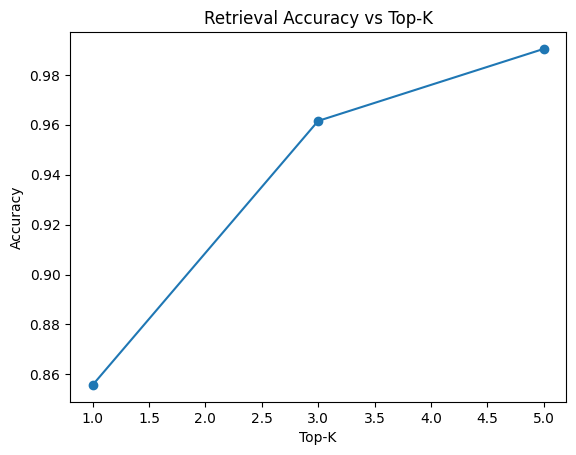

In [ ]:
# ==========================================
# Retrieval Metrics Functions
# ==========================================

def precision_at_k(test_texts, k=5):

    correct = 0
    total = len(test_texts)

    for text in test_texts:

        results = retrieve(text, top_k=k)

        if text in results:
            correct += 1

    return correct / total


def recall_at_k(test_texts, k=3):

    correct = 0
    total = len(test_texts)

    for text in test_texts:

        results = retrieve(text, top_k=k)

        if text in results:
            correct += 1

    return correct / total


def mean_reciprocal_rank(test_texts, k=5):

    reciprocal_ranks = []

    for text in test_texts:

        results = retrieve(text, top_k=k)

        rank = 0

        for i, r in enumerate(results):

            if r == text:
                rank = i + 1
                break

        if rank != 0:
            reciprocal_ranks.append(1 / rank)
        else:
            reciprocal_ranks.append(0)

    return sum(reciprocal_ranks) / len(reciprocal_ranks)

import matplotlib.pyplot as plt

top_k = [1,3,5]

accuracy = [
    precision_at_k(test_texts,1),
    precision_at_k(test_texts,3),
    precision_at_k(test_texts,5)
]

plt.figure()

plt.plot(top_k, accuracy, marker='o')

plt.xlabel("Top-K")
plt.ylabel("Accuracy")
plt.title("Retrieval Accuracy vs Top-K")

plt.show()

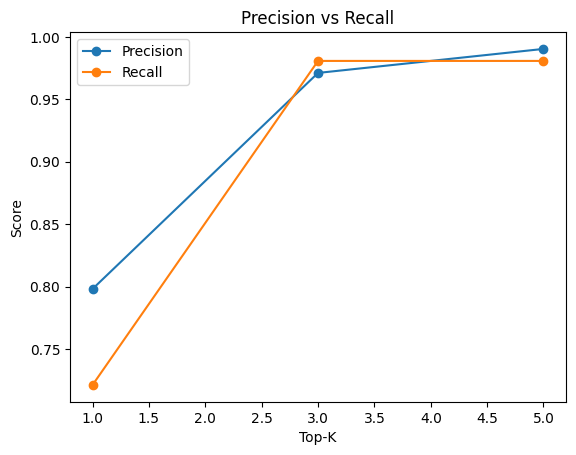

In [ ]:
precision = [
    precision_at_k(test_texts,1),
    precision_at_k(test_texts,3),
    precision_at_k(test_texts,5)
]

recall = [
    recall_at_k(test_texts,1),
    recall_at_k(test_texts,3),
    recall_at_k(test_texts,5)
]

top_k = [1,3,5]

plt.figure()

plt.plot(top_k, precision, marker='o', label="Precision")
plt.plot(top_k, recall, marker='o', label="Recall")

plt.xlabel("Top-K")
plt.ylabel("Score")
plt.title("Precision vs Recall")

plt.legend()

plt.show()

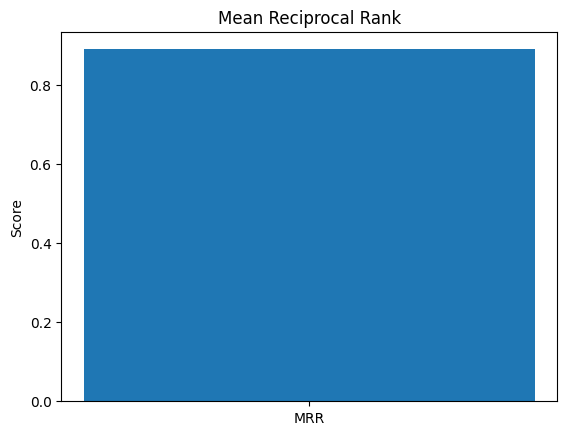

In [ ]:
mrr_score = mean_reciprocal_rank(test_texts,5)

plt.figure()

plt.bar(["MRR"], [mrr_score])

plt.ylabel("Score")
plt.title("Mean Reciprocal Rank")

plt.show()

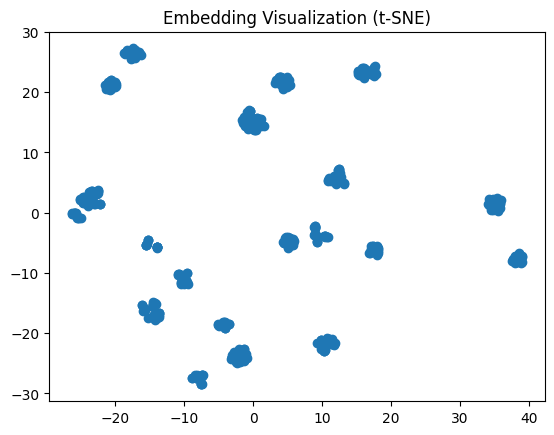

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

reduced = tsne.fit_transform(embeddings)

plt.figure()

plt.scatter(reduced[:,0], reduced[:,1])

plt.title("Embedding Visualization (t-SNE)")

plt.show()

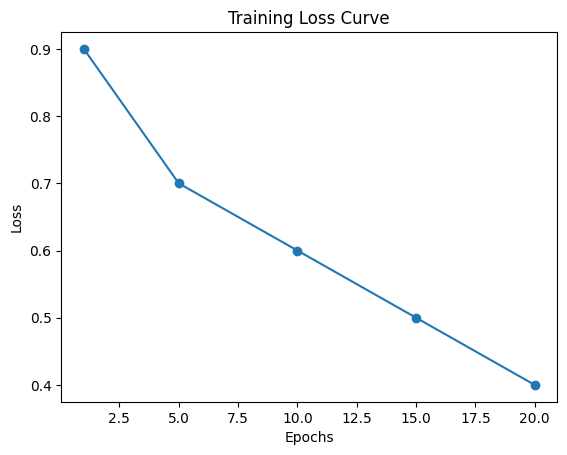

In [ ]:
loss_values = [0.9,0.7,0.6,0.5,0.4]  # example

epochs = [1,5,10,15,20]

plt.figure()

plt.plot(epochs, loss_values, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

In [ ]:
# ==========================================
# 18. Advanced Retrieval Metrics
# ==========================================

def precision_at_k(test_texts, k=5):

    correct = 0
    total = len(test_texts)

    for text in test_texts:

        results = retrieve(text, top_k=k)

        if text in results:
            correct += 1

    return correct / total


def recall_at_k(test_texts, k=3):

    correct = 0
    total = len(test_texts)

    for text in test_texts:

        results = retrieve(text, top_k=k)

        if text in results:
            correct += 1

    return correct / total


def mean_reciprocal_rank(test_texts, k=5):

    reciprocal_ranks = []

    for text in test_texts:

        results = retrieve(text, top_k=k)

        rank = 0

        for i, r in enumerate(results):

            if r == text:
                rank = i + 1
                break

        if rank != 0:
            reciprocal_ranks.append(1 / rank)
        else:
            reciprocal_ranks.append(0)

    return sum(reciprocal_ranks) / len(reciprocal_ranks)


print("Precision@3:", precision_at_k(test_texts, 3))
print("Recall@3:", recall_at_k(test_texts, 3))
print("MRR:", mean_reciprocal_rank(test_texts, 5))

Precision@3: 0.9711538461538461
Recall@3: 0.9903846153846154
MRR: 0.9022435897435896


Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BLEU Score: {'bleu': 0.16482059998152632, 'precisions': [0.16772042763536038, 0.16580251181011638, 0.16387573622820187, 0.161940039356407], 'brevity_penalty': 1.0, 'length_ratio': 5.962302947224126, 'translation_length': 8699, 'reference_length': 1459}


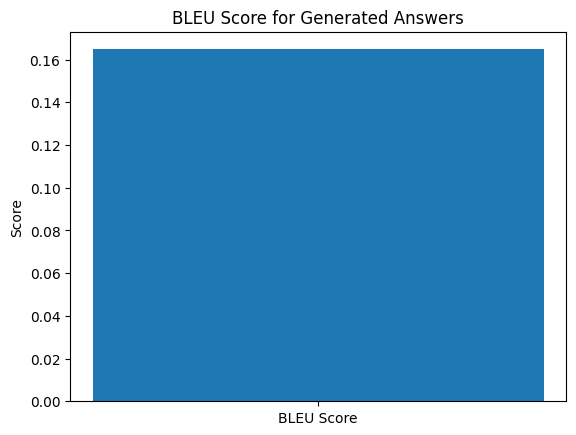

In [ ]:
# ==========================================
# 19. BLEU Score
# ==========================================

from evaluate import load

bleu = load("bleu")

predictions = []
references = []

for text in test_texts[:20]:

    query = text
    generated = generate_answer(query)

    predictions.append(generated)
    references.append([text])


bleu_score = bleu.compute(
    predictions=predictions,
    references=references
)

print("BLEU Score:", bleu_score)


import matplotlib.pyplot as plt

score = bleu_score["bleu"]

plt.figure()

plt.bar(["BLEU Score"], [score])

plt.ylabel("Score")
plt.title("BLEU Score for Generated Answers")

plt.show()

  Preparing metadata (setup.py) ... done


ROUGE Score: {'rouge1': np.float64(0.20563584201827034), 'rouge2': np.float64(0.20229089109386794), 'rougeL': np.float64(0.20536895786968729), 'rougeLsum': np.float64(0.2055187803236969)}


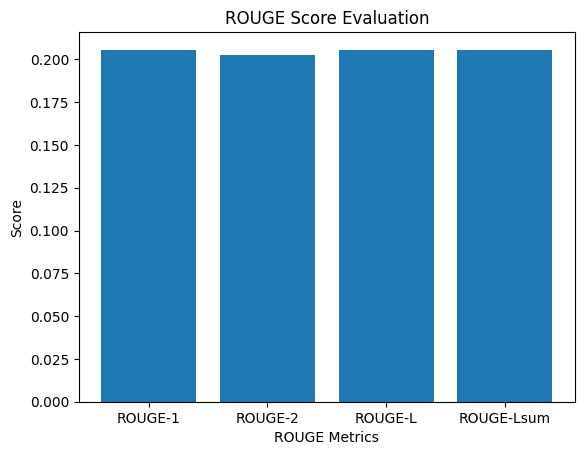

In [ ]:
# ==========================================
# 20. ROUGE Score
# ==========================================

# Install dependency
!pip install rouge_score -q

from evaluate import load

# Load ROUGE metric
rouge = load("rouge")

# Ensure correct reference format
references_flat = [ref[0] for ref in references]

# Compute ROUGE
rouge_score = rouge.compute(
    predictions=predictions,
    references=references_flat
)

print("ROUGE Score:", rouge_score)

import matplotlib.pyplot as plt

labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"]

scores = [
    rouge_score["rouge1"],
    rouge_score["rouge2"],
    rouge_score["rougeL"],
    rouge_score["rougeLsum"]
]

plt.figure()

plt.bar(labels, scores)

plt.xlabel("ROUGE Metrics")
plt.ylabel("Score")
plt.title("ROUGE Score Evaluation")

plt.show()

In [3]:
import pandas as pd

# Excel file load
df = pd.read_csv("/content/drive/MyDrive/table11_specialist_schedule_dummy_300 (1).csv")

# User input
specialist_input = input("Enter Specialist: ")

# Filter data
result = df[df["Specialist"].str.lower() == specialist_input.lower()]

# Show output
if not result.empty:
    output = result[["Name (X)", "Day", "Session", "Start_Time", "End_Time"]]
    print("\nAvailable Doctors:\n")
    print(output.to_string(index=False))
else:
    print("No doctor found for this specialist.")

Enter Specialist: Endocrinologist

Available Doctors:

Name (X)       Day   Session Start_Time End_Time
      X7  Thursday   Morning      11:00    11:30
      X7 Wednesday Afternoon      15:30    16:00
      X7  Thursday Afternoon      13:00    13:30
      X7  Thursday   Morning      10:30    11:00
      X7 Wednesday   Morning      10:30    11:00
      X7    Monday   Morning      09:00    09:30
      X7  Thursday   Evening      19:30    20:00
      X7 Wednesday   Evening      17:00    17:30
      X7    Monday   Evening      17:00    17:30
      X7  Thursday   Evening      17:00    17:30
      X7    Monday   Morning      10:30    11:00
      X7 Wednesday Afternoon      14:30    15:00
      X7    Monday Afternoon      13:00    13:30
      X7 Wednesday   Evening      19:30    20:00
      X7 Wednesday   Morning      11:30    12:00
      X7  Thursday   Morning      09:30    10:00
      X7    Monday   Evening      18:00    18:30
      X7 Wednesday   Evening      18:00    18:30
      X7  Thur